In [185]:
import numpy as np

#--------------------------------------------------
# TensorFlow importieren
#-------------------------------------------------
import tensorflow as tf
import os

import datetime
import matplotlib.pyplot as plt

import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

In [186]:
#--------------------------------------------------
# Laden des NNIST-Datensatzes mittels Keras
#--------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

#--------------------------------------------------
# Flatten
#--------------------------------------------------
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)

#--------------------------------------------------
# Normieren
#--------------------------------------------------
X_train   = X_train / 255
X_test  = X_test  / 255

#--------------------------------------------------
# One-Hot-Kodierung
#--------------------------------------------------
y_train_oneHot = tf.keras.utils.to_categorical(y_train, 10)
y_test_oneHot = tf.keras.utils.to_categorical(y_test, 10)

In [187]:
print(y_train_oneHot[0:10,:])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [188]:
#--------------------------------------------------
# Modell laden (hier: Sequentiell)
#--------------------------------------------------
from tensorflow.keras.models import Sequential

init_kernel = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
init_bias   = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)

#--------------------------------------------------
# Modell generieren
#--------------------------------------------------
model_fcn = Sequential()
model_fcn.add(tf.keras.layers.Dense(64, activation="sigmoid", kernel_initializer = init_kernel, bias_initializer = init_bias, input_shape=(28*28,)))
model_fcn.add(tf.keras.layers.Dense(32, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.Dense(10, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))

model_fcn.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [189]:
#--------------------------------------------------
# Modell kompilieren
#--------------------------------------------------
def my_mse(y_true,y_pred):
    L = tf.reduce_mean(tf.square(tf.subtract(y_true,y_pred)))
    return L

In [190]:
#--------------------------------------------------
# Modell kompilieren
#--------------------------------------------------
model_fcn.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.5), loss=my_mse, metrics=['accuracy'])

#--------------------------------------------------
# Modell trainieren
#--------------------------------------------------
history_fcn = model_fcn.fit(X_train, y_train_oneHot, batch_size=30, epochs=100, verbose=1)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 768us/step - accuracy: 0.2268 - loss: 0.0918
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 768us/step - accuracy: 0.2268 - loss: 0.0918
Epoch 2/100
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step - accuracy: 0.4693 - loss: 0.0710
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step - accuracy: 0.4693 - loss: 0.0710
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 791us/step - accuracy: 0.5531 - loss: 0.0603
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 791us/step - accuracy: 0.5531 - loss: 0.0603
Epoch 4/100
   1/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.5667 - loss: 0.0616Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 777us/step - accuracy: 0.5963 - loss: 0.0547
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 777us/step - accuracy: 0.5963 - loss: 0.0547
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 784us/step - accuracy: 0.6215 - loss: 0.0510
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 784us/step - accuracy: 0.6215 - loss: 0.0510
Epoch 6/100


------------------------------------------
Klassifikationsgenauigkeit (Trainingsende)
------------------------------------------
94.64666843414307  Prozent


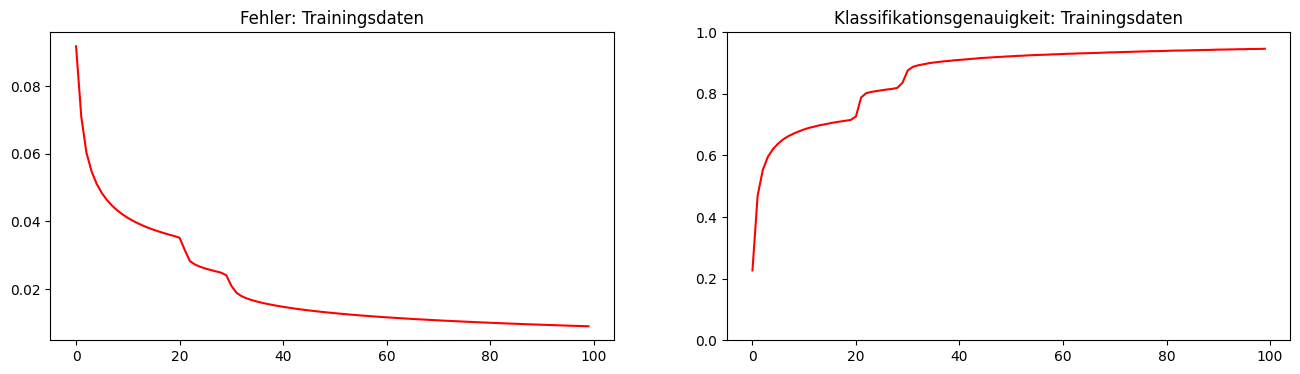

In [191]:
fig, ax = plt.subplots(1,2, squeeze=False,figsize=(16, 4))

ax[0,0].plot(history_fcn.history['loss'],"r")
ax[0,1].plot(history_fcn.history['accuracy'],"r")
ax[0,1].set_ylim([0,1])


ax[0,0].set_title("Fehler: Trainingsdaten")
t=ax[0,1].set_title("Klassifikationsgenauigkeit: Trainingsdaten")

print("------------------------------------------")
print("Klassifikationsgenauigkeit (Trainingsende)")
print("------------------------------------------")
print(np.max(history_fcn.history['accuracy'])*100 , " Prozent")

In [192]:
# klassifikation auf Testdaten durchführen
test_loss, test_accuracy = model_fcn.evaluate(X_test, y_test_oneHot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.9331 - loss: 0.0105
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.9331 - loss: 0.0105


In [193]:
print(test_loss)
print(test_accuracy)


0.010522007942199707
0.9330999851226807


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


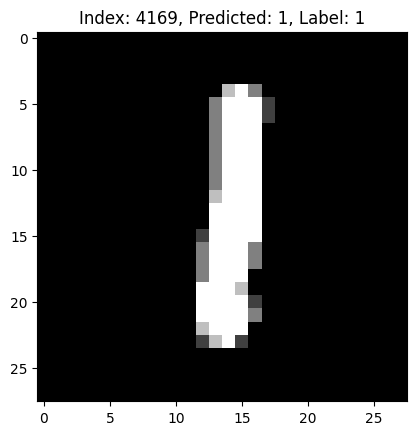

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


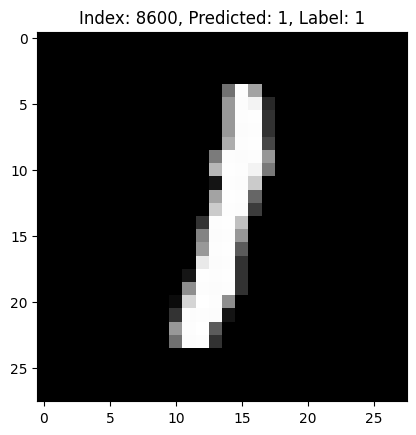

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


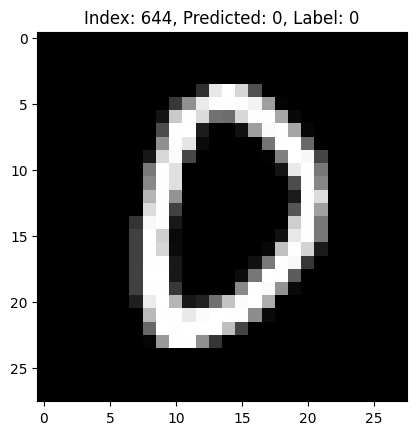

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


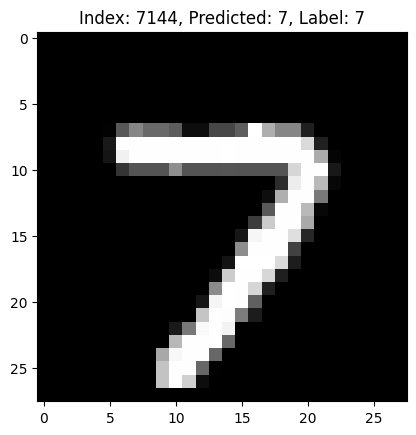

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


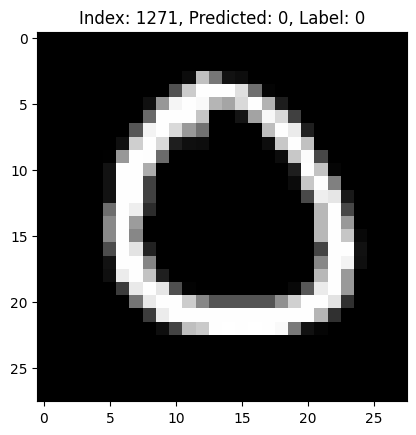

In [194]:
# 10 random numbers from test set
random_indices = np.random.randint(0, X_test.shape[0], size=5)

for index in random_indices:
    example_image = X_test[index,:].reshape(1,28*28)
    example_label = y_test[index]
    example_prediction = model_fcn.predict(example_image)
    predicted_label = np.argmax(example_prediction)

    #print(f'index {index}')
    #print(f'predicted {predicted_label}')
    #print(f'actual {example_label}')

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {example_label}')
    plt.show()


In [195]:
# identify and print misclassified examples
predictions = model_fcn.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(predicted_labels != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step


Falsche Klassifizierungen: 669


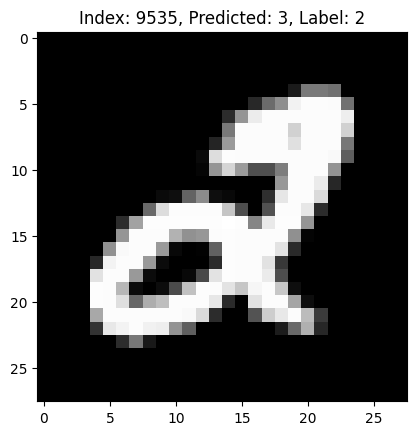

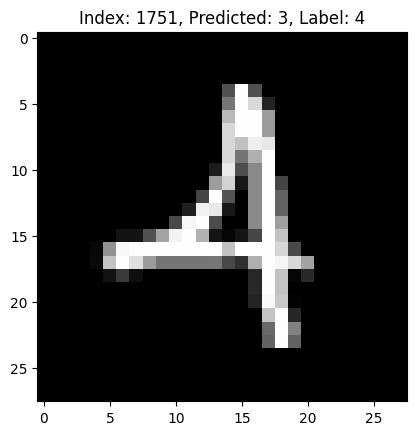

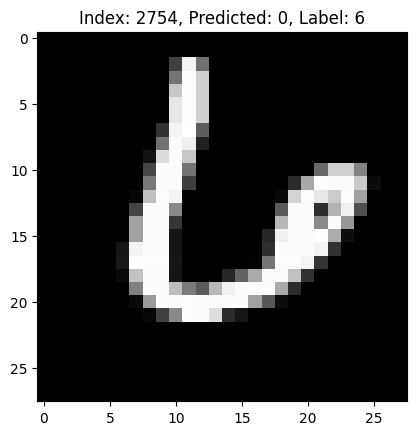

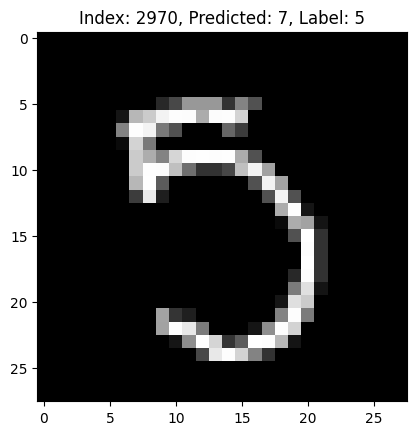

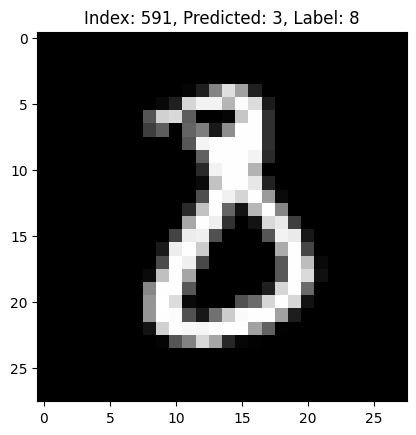

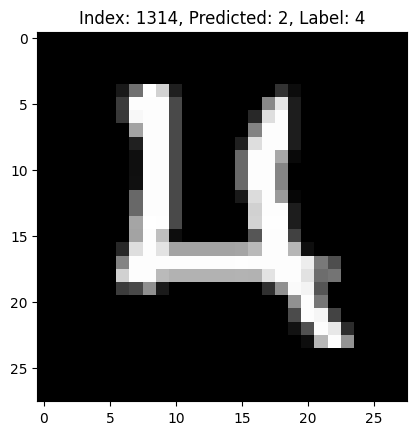

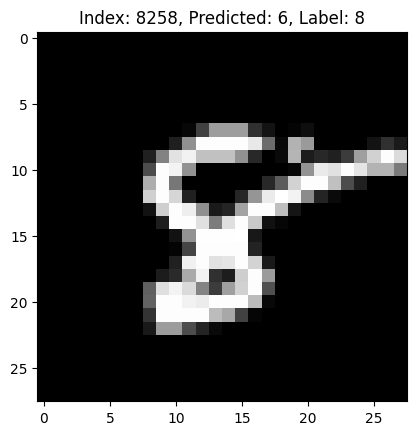

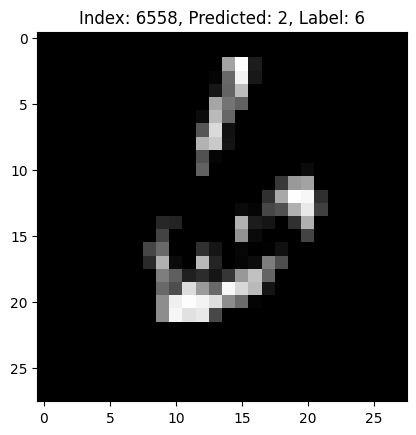

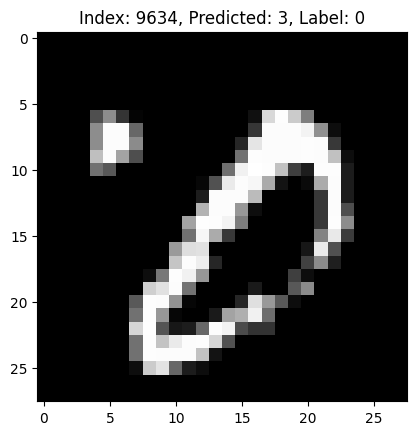

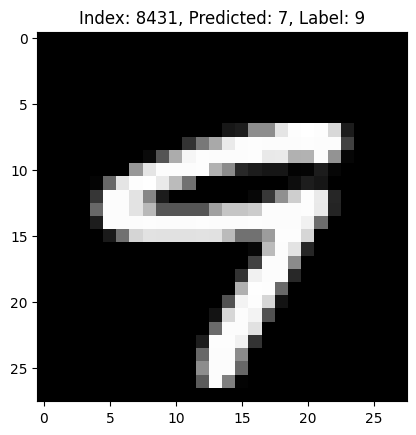

In [196]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


# print number of misclassified examples
indices = np.random.randint(0, misclassified_indices.shape[0], size=10)

for id in indices:
    index = misclassified_indices[id]
    example_image = X_test[index,:].reshape(28,28)
    predicted_label = predicted_labels[index]
    actual_label = y_test[index]

    plt.figure()
    plt.imshow(example_image, cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {actual_label}')
    plt.show()

In [197]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


Falsche Klassifizierungen: 669
